<a href="https://colab.research.google.com/github/biruk50/Medium_articles/blob/main/Three_coloring_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import heapq
def three_coloring(cycles, node_info, graph):
    """
    Greedy 3-coloring using:
    - max heap for cycles
    - min heap for nodes
    """

    # --- Build max heap for cycles ---
    cycle_heap = []
    for cid, cdata in cycles.items():
        heapq.heappush(cycle_heap, (-len(cdata['nodes']), cid))

    def process_cycle_nodes(cycle_nodes):
        """
        Build min heap based on Available colors after pruning neighbor colors
        """
        node_heap = []

        for node in cycle_nodes:
            for neigh in graph.neighbors(node):
                temp = node_info[neigh]['color']
                if temp != 0 and temp in node_info[node]['Available']:
                    node_info[node]['Available'].discard(temp)

            if len(node_info[node]['Available']) == 0:
                return False, None

            heapq.heappush(node_heap, (len(node_info[node]['Available']), node))

        return True, node_heap

    # --- Process cycles ---
    while cycle_heap:
        _, cid = heapq.heappop(cycle_heap)
        current_cycle = cycles[cid]['nodes']

        ok, node_heap = process_cycle_nodes(current_cycle)
        if not ok: return False, node_info

        # Assign colors greedily
        while node_heap:
            _, node = heapq.heappop(node_heap)

            if node_info[node]['color'] != 0:
                continue

            if not node_info[node]['Available']:
                return False, node_info

            color = min(node_info[node]['Available'])
            node_info[node]['color'] = color

            # Update neighbors
            for neigh in graph.neighbors(node):
                if color in node_info[neigh]['Available']:
                    node_info[neigh]['Available'].discard(color)

                if not node_info[neigh]['Available']:
                        return False, node_info

                # push updated priority (lazy update)
                heapq.heappush(
                    node_heap,
                    (len(node_info[neigh]['Available']), neigh)
                )

    return True, node_info

In [ ]:

import heapq
import networkx as nx
from collections import deque

# ---------------- BFS CYCLE FINDER ----------------
def bfs_find_smallest_cycles(graph):
    node_info = {
        node: {'cycle': None, 'visited': 0, 'color': 0, 'Available': {1, 2 , 3}}
        for node in graph.nodes()
    }

    cycles = {}
    cycle_counter = 0

    def extract_cycle_path(u, v, parent):
        path_u, path_v = [], []

        while u is not None:
            path_u.append(u)
            u = parent.get(u)

        while v is not None:
            path_v.append(v)
            v = parent.get(v)

        set_u = set(path_u)
        lca = next((x for x in path_v if x in set_u), None)

        path1 = []
        x = path_u[0]
        while x != lca:
            path1.append(x)
            x = parent[x]
        path1.append(lca)

        path2 = []
        x = path_v[0]
        while x != lca:
            path2.append(x)
            x = parent[x]

        cycle = path1 + path2

        for n in cycle:
            if node_info[n]['cycle'] is not None:
                return None

        return cycle

    for start in graph.nodes():
        if node_info[start]['cycle'] is not None:
            continue

        queue = deque([start])
        parent = {start: None}
        visited_bfs = {start}

        while queue:
            u = queue.popleft()

            for v in graph.neighbors(u):
                if v == parent.get(u):
                    continue

                if v in visited_bfs:
                    cycle = extract_cycle_path(u, v, parent)
                    if cycle:
                        cycle_counter += 1
                        cycles[cycle_counter] = {'nodes': cycle, 'added': False}

                        for n in cycle:
                            node_info[n]['cycle'] = cycle_counter
                else:
                    visited_bfs.add(v)
                    parent[v] = u
                    queue.append(v)

    return cycles, node_info


# ---------------- COLORING ----------------
def three_coloring(cycles, node_info, graph):
    cycle_list = sorted(
        [(cid, len(cdata['nodes'])) for cid, cdata in cycles.items()],
        key=lambda x: x[1],
    )

    visited_cycle = {}
    cycle_heap = []

    def push_cycle(cid):
        heapq.heappush(cycle_heap, (-len(cycles[cid]['nodes']), cid))
        visited_cycle[cid] = True

    def build_node_heap(cycle_nodes):
        node_heap = []

        for node in cycle_nodes:
            for neigh in graph.neighbors(node):
                c = node_info[neigh]['color']
                if c != 0:
                    node_info[node]['Available'].discard(c)

            if not node_info[node]['Available']:
                return False, None

            heapq.heappush(node_heap, (len(node_info[node]['Available']), node))

        return True, node_heap

    while cycle_heap or cycle_list:

        if not cycle_heap:
            while cycle_list:
                cid, _ = cycle_list.pop()
                if not visited_cycle.get(cid):
                    push_cycle(cid)
                    break

        if not cycle_heap:
            break

        _, cid = heapq.heappop(cycle_heap)
        current_cycle = cycles[cid]['nodes']

        ok, node_heap = build_node_heap(current_cycle)
        if not ok:
            return False, node_info

        while node_heap:
            size, node = heapq.heappop(node_heap)

            if size != len(node_info[node]['Available']):
                continue
            if node_info[node]['color'] != 0:
                continue
            if not node_info[node]['Available']:
                return False, node_info

            color = min(node_info[node]['Available'])
            node_info[node]['color'] = color

            for neigh in graph.neighbors(node):
                if node_info[neigh]['color'] != 0:
                    continue

                if color in node_info[neigh]['Available']:
                    node_info[neigh]['Available'].discard(color)

                    if not node_info[neigh]['Available']:
                        return False, node_info

                    heapq.heappush(
                        node_heap,
                        (len(node_info[neigh]['Available']), neigh)
                    )

        for node in current_cycle:
            for neigh in graph.neighbors(node):
                neigh_cycle = node_info[neigh]['cycle']
                if neigh_cycle is not None and not visited_cycle.get(neigh_cycle):
                    push_cycle(neigh_cycle)

    return True, node_info

In [ ]:
import heapq

def three_coloring_degree_weighted(cycles, node_info, graph):
    degree_dict = {node: graph.degree[node] for node in graph.nodes()}

    # --- build cycle weights ---
    cycle_weights = {
        cid: sum(degree_dict[n] for n in cdata['nodes'])
        for cid, cdata in cycles.items()
    }

    cycle_list = sorted(
        [(cid, cycle_weights[cid]) for cid in cycles],
        key=lambda x: x[1],
    )

    visited_cycle = {}
    cycle_heap = []

    def push_cycle(cid):
        heapq.heappush(cycle_heap, (-cycle_weights[cid], cid))
        visited_cycle[cid] = True

    def build_node_heap(cycle_nodes):
        node_heap = []

        for node in cycle_nodes:
            for neigh in graph.neighbors(node):
                c = node_info[neigh]['color']
                if c != 0:
                    node_info[node]['Available'].discard(c)

            if not node_info[node]['Available']:
                return False, None

            heapq.heappush(node_heap, (len(node_info[node]['Available']), node))

        return True, node_heap

    # --- main loop ---
    while cycle_heap or cycle_list:

        if not cycle_heap:
            while cycle_list:
                cid, _ = cycle_list.pop()
                if not visited_cycle.get(cid):
                    push_cycle(cid)
                    break

        if not cycle_heap:
            break

        _, cid = heapq.heappop(cycle_heap)
        current_cycle = cycles[cid]['nodes']

        ok, node_heap = build_node_heap(current_cycle)
        if not ok:
            return False, node_info

        while node_heap:
            size, node = heapq.heappop(node_heap)

            if size != len(node_info[node]['Available']):
                continue
            if node_info[node]['color'] != 0:
                continue
            if not node_info[node]['Available']:
                return False, node_info

            color = min(node_info[node]['Available'])
            node_info[node]['color'] = color

            for neigh in graph.neighbors(node):
                if node_info[neigh]['color'] != 0:
                    continue

                if color in node_info[neigh]['Available']:
                    node_info[neigh]['Available'].discard(color)

                    if not node_info[neigh]['Available']:
                        return False, node_info

                    heapq.heappush(
                        node_heap,
                        (len(node_info[neigh]['Available']), neigh)
                    )

        # --- discover connected cycles ---
        for node in current_cycle:
            for neigh in graph.neighbors(node):
                neigh_cycle = node_info[neigh]['cycle']
                if neigh_cycle is not None and not visited_cycle.get(neigh_cycle):
                    push_cycle(neigh_cycle)

    return True, node_info

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx


def draw_colored_graph(G, node_info, title="Graph Coloring"):
    color_map = {
        1: "red",
        2: "green",
        3: "blue",
        0: "lightgray"
    }

    node_colors = [
        color_map[node_info[n]['color']]
        for n in G.nodes()
    ]

    pos = nx.spring_layout(G, seed=42)  # stable layout

    plt.figure(figsize=(10, 8))
    nx.draw(
        G,
        pos,
        node_color=node_colors,
        with_labels=False,
        node_size=50,
        edge_color="gray"
    )

    plt.title(title)
    plt.show()

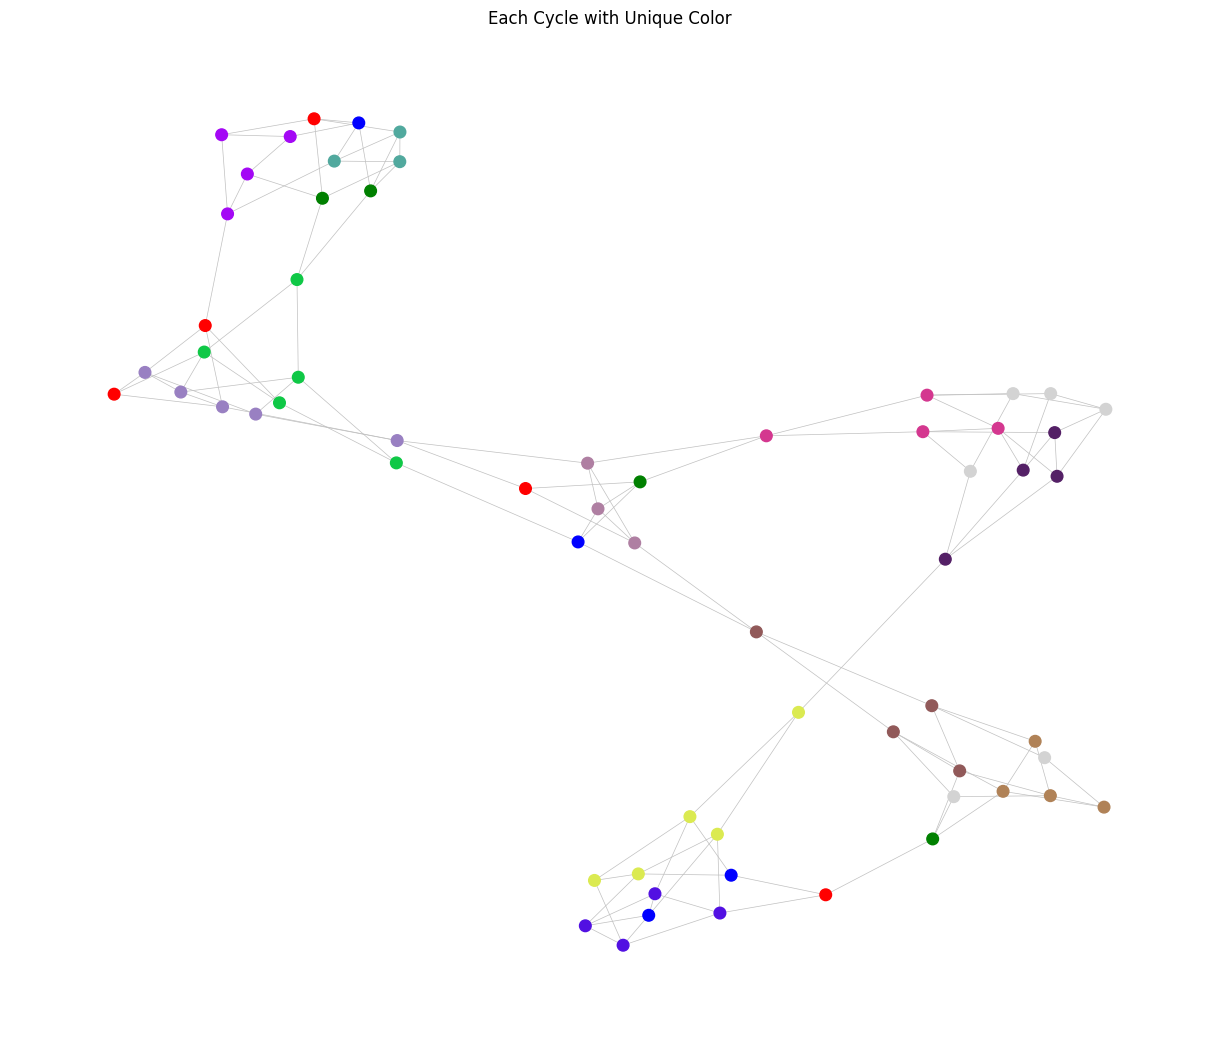

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import random
import matplotlib.colors as mcolors

def draw_cycles_graph(G, cycles, node_info, title="Cycles Visualization"):
    """
    Visualize cycles with distinct colors:
    - Each cycle ID gets a unique randomly generated color
    - Nodes not in a cycle use their assigned logical color (1, 2, 3) or gray
    """
    # Generate a unique color for every cycle ID found
    cycle_colors = {}
    for cid in cycles:
        # Using random RGB values for maximum variety
        cycle_colors[cid] = (random.random(), random.random(), random.random())

    base_color_map = {
        1: "red",
        2: "green",
        3: "blue",
        0: "lightgray"
    }

    node_colors = []
    for node in G.nodes():
        cid = node_info[node].get('cycle')

        if cid is not None and cid in cycle_colors:
            node_colors.append(cycle_colors[cid])
        else:
            # Default to coloring logic if not part of a detected cycle
            color_val = node_info[node].get('color', 0)
            node_colors.append(base_color_map.get(color_val, "lightgray"))

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(12, 10))
    nx.draw(
        G,
        pos,
        node_color=node_colors,
        with_labels=False,
        node_size=70,
        edge_color="silver",
        width=0.5
    )

    plt.title(title)
    plt.show()

try:
    draw_cycles_graph(G, cycles, node_info, "Each Cycle with Unique Color")
except NameError:
    print("Graph variables not yet initialized. Please run the generation cells first.")

In [ ]:
import networkx as nx
import random


def generate_hard_3color(n=200, p=0.5):
    G = nx.Graph()

    partitions = {i: i % 3 for i in range(n)}
    G.add_nodes_from(range(n))

    for i in range(n):
        for j in range(i + 1, n):
            if partitions[i] != partitions[j] and random.random() < p:
                G.add_edge(i, j)

    return G

In [ ]:
import networkx as nx
import random


def pigeonhole_3color(n=60, density=0.8):
    """
    Hard 3-colorable graph inspired by pigeonhole constraints
    """
    G = nx.Graph()

    # assign hidden true coloring
    true_color = {i: random.randint(1, 3) for i in range(n)}

    G.add_nodes_from(range(n))

    # add strong constraints
    for i in range(n):
        for j in range(i + 1, n):

            # forbid same color edges (normal coloring constraint)
            if true_color[i] == true_color[j]:
                continue

            # add many cross edges (tight constraint)
            if random.random() < density:
                G.add_edge(i, j)

    return G, true_color

In [ ]:
def pigeonhole_chain(n=90):
    G = nx.Graph()

    # groups of 3 → force color cycling
    for i in range(0, n, 3):
        a, b, c = i, i+1, i+2

        G.add_edges_from([
            (a, b), (b, c), (c, a)  # triangle = forces 3 colors
        ])

        if i > 0:
            # connect to previous group (propagation constraint)
            G.add_edge(i, i-1)
            G.add_edge(i+1, i-2)
            G.add_edge(i+2, i-3)

    return G

Cycles found: 101
3-color success: True
Colors used: {1, 2, 3}


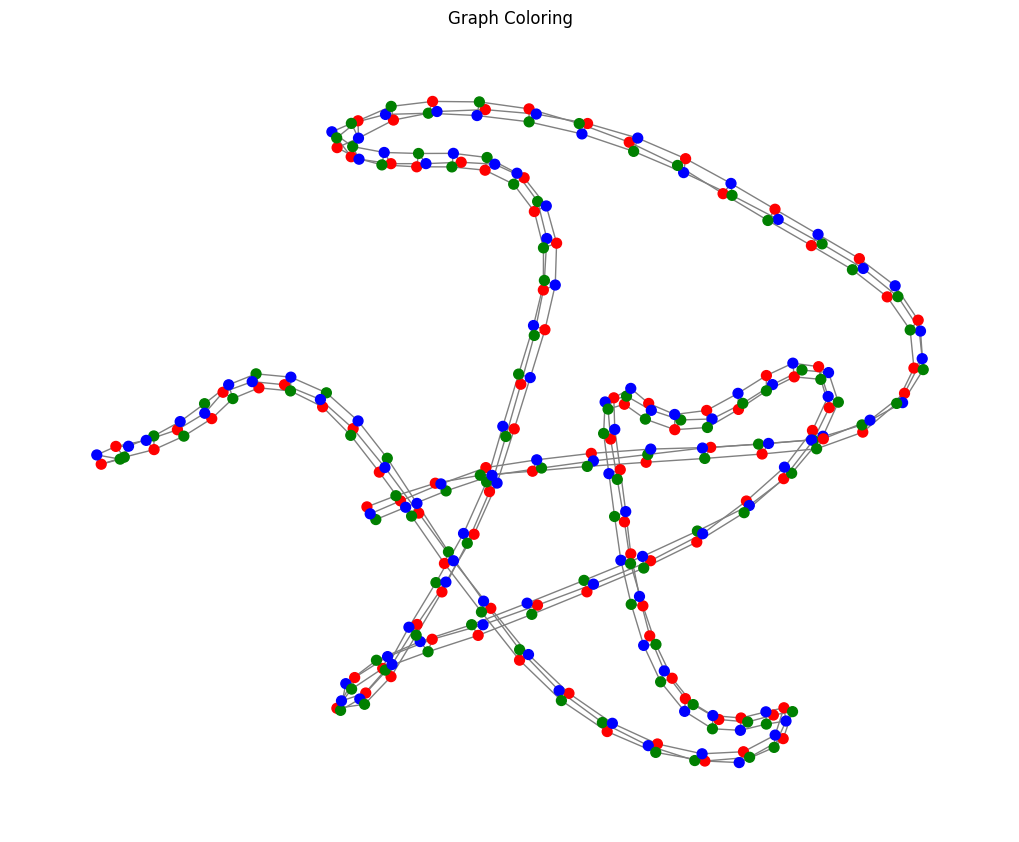

In [ ]:
#G=generate_hard_3color()
#G,_ = pigeonhole_3color(40, 0.7)
G= pigeonhole_chain(290)
cycles, node_info = bfs_find_smallest_cycles(G)

print("Cycles found:", len(cycles))

ok, node_info = three_coloring(cycles, node_info, G)

print("3-color success:", ok)

if ok:
    colors = {node_info[n]['color'] for n in G.nodes()}
    print("Colors used:", colors)
else:
    print("not 3 colorable")
draw_colored_graph(G, node_info)

In [ ]:
import random
import networkx as nx


def get_degree_leq3_edges(G):
    return [(u, v) for u, v in G.edges() if G.degree(u) <= 3]


def pick_valid_edge(G):
    edges = get_degree_leq3_edges(G)
    if not edges:
        raise ValueError("No valid edge with deg(u) ≤ 3")
    return random.choice(edges)


def embed_mug_exact(G, mug):
    G = G.copy()
    H = mug.copy()

    # --- STEP 1: pick (i, j) in G ---
    i, j = pick_valid_edge(G)

    # --- STEP 2: pick (x, y) in MUG ---
    valid_edges = [(x, y) for x, y in H.edges() if H.degree(x) <= 3]
    if not valid_edges:
        raise ValueError("No valid (x,y) in MUG")

    x, y = random.choice(valid_edges)

    # --- STEP 3: relabel H ---
    offset = max(G.nodes()) + 1
    mapping = {n: n + offset for n in H.nodes()}
    H = nx.relabel_nodes(H, mapping)

    x, y = mapping[x], mapping[y]

    # --- STEP 4: remove edges ---
    G.remove_edge(i, j)
    H.remove_edge(x, y)

    # --- STEP 5: merge x into i ---
    for neigh in list(H.neighbors(x)):
        if neigh != x:
            G.add_edge(i, neigh)

    H.remove_node(x)

    # --- STEP 6: add edge (j, y) ---
    G.add_edge(j, y)

    # --- STEP 7: combine ---
    G = nx.compose(G, H)

    return G


def graph_generator(k, get_mug_graph):
    G = get_mug_graph(random.choice(MUG_TYPES))

    for _ in range(k):
        mug = get_mug_graph(random.choice(MUG_TYPES))
        G = embed_mug_exact(G, mug)

    # final step: remove ONE edge → 3-colorable
    G.remove_edge(*random.choice(list(G.edges())))

    return G


Graph is 3-colorable


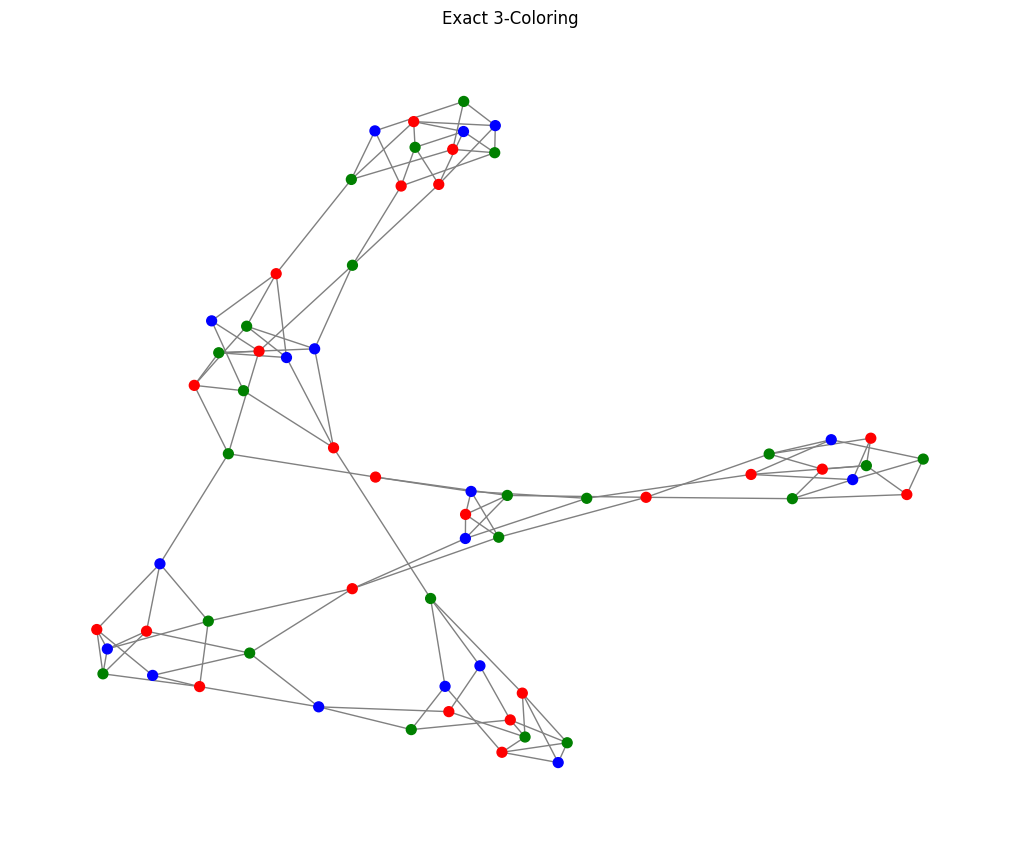

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt


# ---------------- EXACT SOLVER (RETURNS COLORING) ----------------
def find_3_coloring(G):
    nodes = sorted(G.nodes(), key=lambda x: -G.degree(x))
    color = {}

    def valid(node, c):
        for neigh in G.neighbors(node):
            if color.get(neigh) == c:
                return False
        return True

    def dfs(i):
        if i == len(nodes):
            return True

        node = nodes[i]

        for c in (1, 2, 3):
            if valid(node, c):
                color[node] = c
                if dfs(i + 1):
                    return True
                del color[node]

        return False

    if dfs(0):
        return color
    return None


# ---------------- DRAW ----------------
def draw_colored_graph(G, node_info, title="Graph Coloring"):
    color_map = {
        1: "red",
        2: "green",
        3: "blue",
        0: "lightgray"
    }

    node_colors = [
        color_map[node_info[n]['color']]
        for n in G.nodes()
    ]

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(10, 8))
    nx.draw(
        G,
        pos,
        node_color=node_colors,
        with_labels=False,
        node_size=50,
        edge_color="gray"
    )

    plt.title(title)
    plt.show()


# ---------------- INTEGRATION ----------------
def draw_if_3_colorable(G):
    coloring = find_3_coloring(G)

    if coloring is None:
        print("Graph is NOT 3-colorable")
        return

    print("Graph is 3-colorable")

    # convert to your node_info format
    node_info = {
        n: {'color': coloring[n]}
        for n in G.nodes()
    }

    draw_colored_graph(G, node_info, title="Exact 3-Coloring")


# ---------------- TEST ----------------
if __name__ == "__main__":
    G = graph_generator(5,get_mug_graph)
    draw_if_3_colorable(G)

In [ ]:
import networkx as nx
# ---------------- EXACT 3-COLORING (BACKTRACKING) ----------------
def is_3_colorable(G):
    nodes = list(G.nodes())
    color = {}

    def valid(node, c):
        for neigh in G.neighbors(node):
            if color.get(neigh) == c:
                return False
        return True

    def dfs(i):
        if i == len(nodes):
            return True

        node = nodes[i]

        for c in (1, 2, 3):
            if valid(node, c):
                color[node] = c
                if dfs(i + 1):
                    return True
                del color[node]

        return False

    return dfs(0)


# ---------------- SAFE GENERATOR ----------------
def generate_safe_graph(generator_func, max_tries=50):
    """
    Keep generating until we get guaranteed 3-colorable graph.
    """
    for attempt in range(max_tries):
        G = generator_func()

        if is_3_colorable(G):
            print(f"[OK] Found 3-colorable graph on attempt {attempt+1}")
            return G

    raise RuntimeError("Failed to generate 3-colorable graph")


# ---------------- TEST ----------------
if __name__ == "__main__":
    def gen():
        return graph_generator(5,get_mug_graph)

    G = generate_safe_graph(gen)

    # compare with greedy
    greedy = nx.algorithms.coloring.greedy_color(G, strategy="largest_first")

    print("Greedy colors used:", len(set(greedy.values())))
    print("Exact says 3-colorable:", is_3_colorable(G))

[OK] Found 3-colorable graph on attempt 1
Greedy colors used: 4
Exact says 3-colorable: True


In [ ]:
import heapq
from collections import deque


def bfs_find_smallest_cycles_maxheap(graph):
    node_info = {
        node: {'cycle': None, 'visited': 0, 'color': 0, 'Available': {1, 2, 3}}
        for node in graph.nodes()
    }

    cycles = {}
    cycle_counter = 0

    # --- build max heap (negative degree) ---
    node_heap = []
    for node in graph.nodes():
        heapq.heappush(node_heap, (-graph.degree[node], node))

    def extract_cycle_path(u, v, parent):
        path_u, path_v = [], []

        while u is not None:
            path_u.append(u)
            u = parent.get(u)

        while v is not None:
            path_v.append(v)
            v = parent.get(v)

        set_u = set(path_u)
        lca = next((x for x in path_v if x in set_u), None)

        path1 = []
        x = path_u[0]
        while x != lca:
            path1.append(x)
            x = parent[x]
        path1.append(lca)

        path2 = []
        x = path_v[0]
        while x != lca:
            path2.append(x)
            x = parent[x]

        cycle = path1 + path2

        for n in cycle:
            if node_info[n]['cycle'] is not None:
                return None

        return cycle

    # --- main loop ---
    while node_heap:
        _, start = heapq.heappop(node_heap)

        if node_info[start]['cycle'] is not None:
            continue

        queue = deque([start])
        parent = {start: None}
        visited_bfs = {start}

        while queue:
            u = queue.popleft()

            for v in graph.neighbors(u):
                if v == parent.get(u):
                    continue

                if v in visited_bfs:
                    cycle = extract_cycle_path(u, v, parent)
                    if cycle:
                        cycle_counter += 1
                        cycles[cycle_counter] = {
                            'nodes': cycle,
                            'added': False
                        }

                        for n in cycle:
                            node_info[n]['cycle'] = cycle_counter
                else:
                    visited_bfs.add(v)
                    parent[v] = u
                    queue.append(v)

    return cycles, node_info

Cycles found: 12
3-color success: False
not 3 colorable


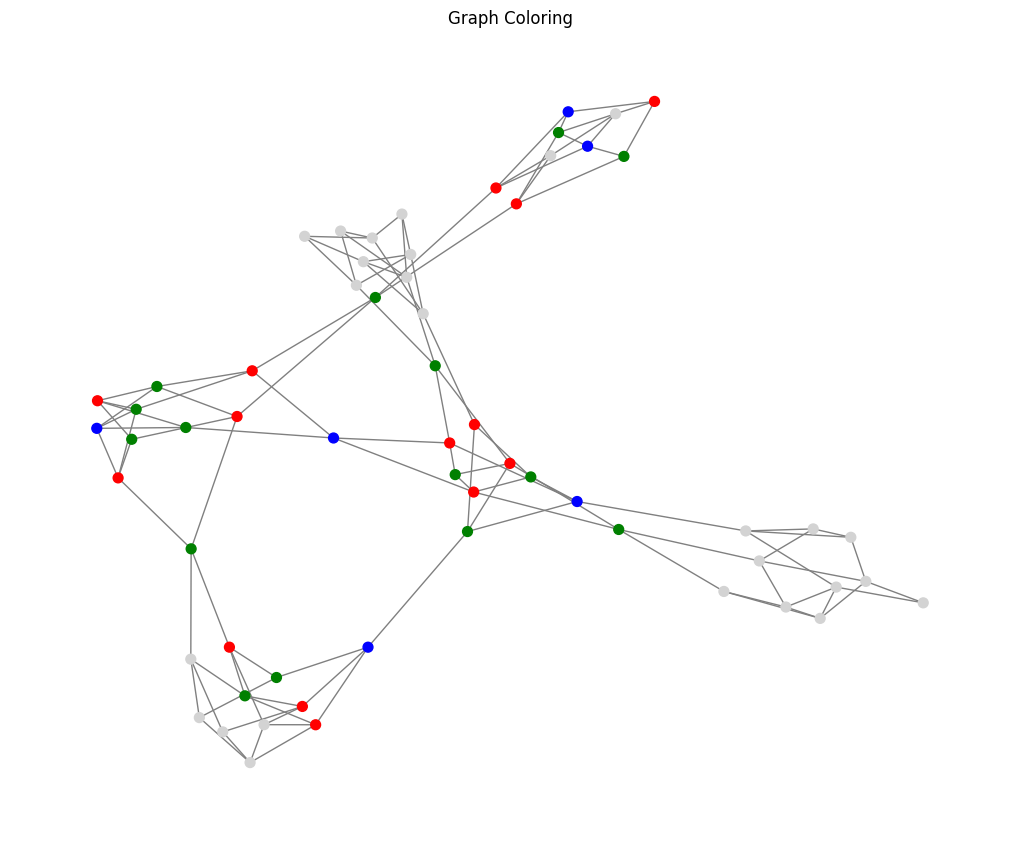

In [ ]:
cycles, node_info = bfs_find_smallest_cycles_maxheap(G)

print("Cycles found:", len(cycles))

ok, node_info = three_coloring(cycles, node_info, G)

print("3-color success:", ok)

if ok:
    colors = {node_info[n]['color'] for n in G.nodes()}
    print("Colors used:", colors)
else:
    print("not 3 colorable")
draw_colored_graph(G, node_info)

Heuristic success: False


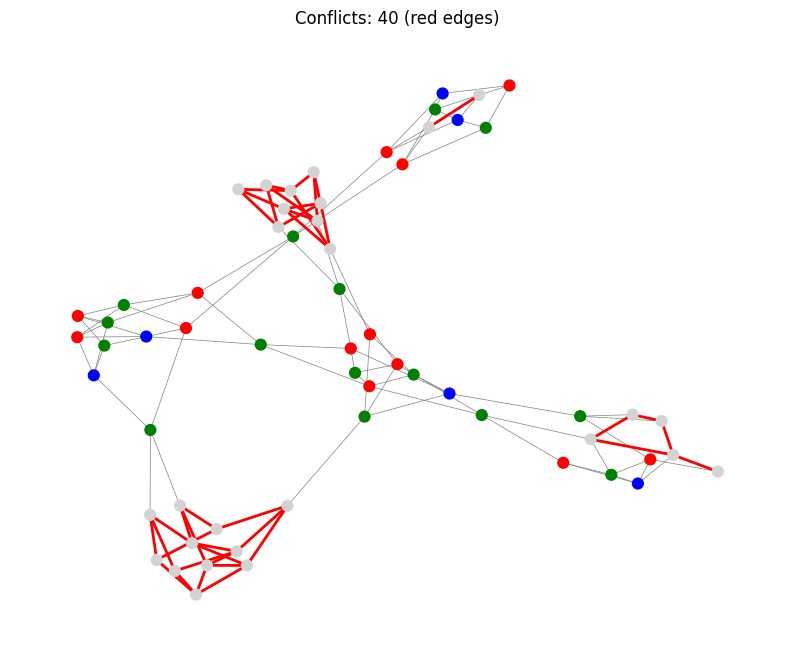

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt


# ---------------- EXACT SOLVER ----------------
def find_3_coloring(G):
    nodes = sorted(G.nodes(), key=lambda x: -G.degree(x))
    color = {}

    def valid(node, c):
        return all(color.get(neigh) != c for neigh in G.neighbors(node))

    def dfs(i):
        if i == len(nodes):
            return True

        node = nodes[i]
        for c in (1, 2, 3):
            if valid(node, c):
                color[node] = c
                if dfs(i + 1):
                    return True
                del color[node]
        return False

    return color if dfs(0) else None


# ---------------- FIND CONFLICTS ----------------
def find_conflicts(G, node_info):
    conflicts = []

    for u, v in G.edges():
        if node_info[u]['color'] == node_info[v]['color']:
            conflicts.append((u, v))

    return conflicts


# ---------------- DRAW ----------------
def draw_comparison(G, heuristic_info, exact_coloring):
    pos = nx.spring_layout(G, seed=42)

    color_map = {1: "red", 2: "green", 3: "blue", 0: "lightgray"}

    node_colors = [
        color_map[heuristic_info[n]['color']]
        for n in G.nodes()
    ]

    conflicts = find_conflicts(G, heuristic_info)

    plt.figure(figsize=(10, 8))

    # normal edges
    nx.draw_networkx_edges(G, pos, edge_color="gray", width=0.5)

    # conflict edges (highlight)
    if conflicts:
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=conflicts,
            edge_color="red",
            width=2
        )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=60
    )

    plt.title(f"Conflicts: {len(conflicts)} (red edges)")
    plt.axis("off")
    plt.show()


# ---------------- INTEGRATION ----------------
def compare_algorithms(G, bfs_func, coloring_func):
    # your algorithm
    cycles, node_info = bfs_func(G)
    ok, heuristic_info = coloring_func(cycles, node_info, G)

    # exact
    exact = find_3_coloring(G)

    if exact is None:
        print("Graph NOT 3-colorable (unexpected)")
        return

    print("Heuristic success:", ok)

    draw_comparison(G, heuristic_info, exact)


# ---------------- TEST ----------------
if __name__ == "__main__":
    G = graph_generator(5,get_mug_graph)

    compare_algorithms(G, bfs_find_smallest_cycles_maxheap, three_coloring)